# Modeling Variance Threshold - Decision Tree - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)

## 1. Objective

Etablir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model

In [5]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate,GridSearchCV,StratifiedGroupKFold
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

RANDOM_STATE = 42

dt =  DecisionTreeClassifier(random_state=RANDOM_STATE)

xtrain_VT = pd.read_csv("xtrain_VT.csv")
ytrain = pd.read_csv("ytrain.csv").squeeze("columns")
kepid_train = pd.read_csv("kepid_train.csv").squeeze("columns")

Stratified_G_Kfold_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=dt,X=xtrain_VT,y=ytrain,groups=kepid_train,scoring="f1_macro",return_train_score=True,cv=Stratified_G_Kfold_cv)
pd.DataFrame(cv_results)

,fit_time,score_time,test_score,train_score
0,0.306381,0.008887,0.642440,1.0
1,0.330812,0.008846,0.646542,1.0
2,0.302780,0.009683,0.658749,1.0
3,0.309733,0.009197,0.693400,1.0
4,0.312543,0.008998,0.660215,1.0


In [6]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  1.0
Mean validation score 0.6602691517296925


Le Decision Tree avec ses paramètres par défaut obtient un F1-macro moyen d’environ 0,660 en validation croisée. Les scores de validation varient entre environ 0,642 et 0,693, ce qui montre une certaine variabilité entre les folds.

En revanche, le F1-macro d’entraînement atteint 1,00 sur les cinq folds. Le modèle parvient donc à classifier parfaitement les données utilisées pour son entraînement.

L’écart très important entre le score d’entraînement (1,00) et le score moyen de validation (0,660) met en évidence un surapprentissage important.

Cette baseline montre que l’arbre est trop complexe dans sa configuration par défaut. L’optimisation des hyperparamètres devra donc chercher à limiter sa complexité afin de réduire le surapprentissage et d’améliorer sa capacité de généralisation

## 3. Hyperparameter Tuning

In [7]:
settings_grid = {
    "max_depth":[None,10,20],
    "min_samples_leaf":[1, 2, 5],
    "max_features":["sqrt", 0.5],
}

grid_search =  GridSearchCV(estimator=dt,param_grid=settings_grid,scoring="f1_macro",cv=Stratified_G_Kfold_cv,return_train_score=True)

grid_search.fit(
    xtrain_VT,
    ytrain,
    groups=kepid_train,
)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 2, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedGro... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [8]:
best_index = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)

print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_index]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_index]
)

Best parameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 2}
Best validation F1: 0.6927386730947294
Mean train F1: 0.8355266893299497
Std validation F1: 0.01677816934273645


L'optimisation du Decision Tree sélectionne une profondeur maximale de 10, un minimum de 2 observations par feuille et 50 % des variables disponibles à chaque séparation.

Le F1-macro moyen de validation atteint 0,693, contre environ 0,660 pour la baseline. Parallèlement, le F1-macro d'entraînement passe d'environ 1,00 à 0,836.

L'écart entre entraînement et validation est donc fortement réduit. La limitation de la complexité de l'arbre permet de diminuer le surapprentissage tout en améliorant sa capacité de généralisation.

Le modèle reste légèrement plus performant sur l'entraînement que sur la validation, mais son comportement est nettement plus équilibré après optimisation

## 4. Final Evaluation

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_VT = pd.read_csv("xtest_VT.csv")
y_test = pd.read_csv("ytest.csv").squeeze("columns")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_VT)

class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy :",accuracy )
print("Precision macro :",precision )
print("Recall macro :",recall )
print("F1 macro :", f1)

Accuracy : 0.7176656151419558
Precision macro : 0.6799521597718546
Recall macro : 0.6892404574675672
F1 macro : 0.6827550637670706


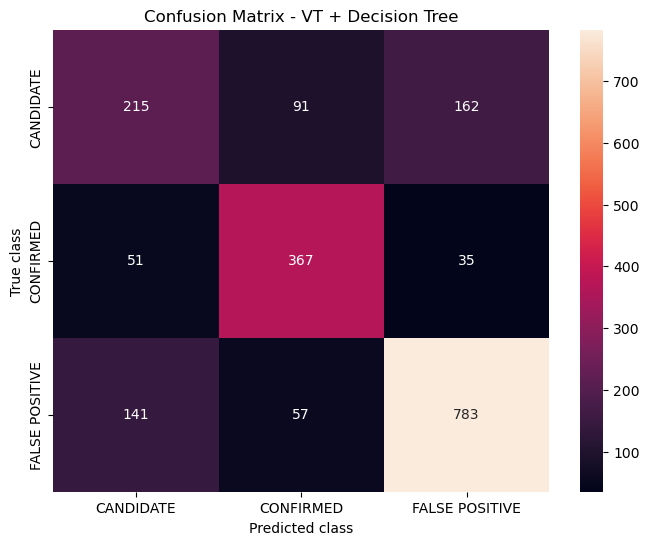

In [10]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - VT + Decision Tree")

plt.show()

Le Decision Tree utilisant la sélection Variance Threshold présente également de bonnes performances pour les classes `CONFIRMED` et FALSE POSITIVE, mais éprouve davantage de difficultés avec la classe CANDIDATE.

Parmi les 468 CANDIDATE, seuls 215 sont correctement identifiés, tandis que 91 sont prédits CONFIRMED et 162 FALSE POSITIVE. Sur les 453 CONFIRMED, 367 sont correctement classés, et sur les 981 FALSE POSITIVE, 783 sont correctement reconnus.

La principale faiblesse du modèle concerne donc la reconnaissance des candidats, avec une tendance relativement importante à les classer comme faux positifs

## 5. Model Limits

Le Decision Tree avec Variance Threshold reste moins performant que le Random Forest, malgré l’utilisation d’un plus grand ensemble de variables. Cela montre qu’un nombre plus important de features ne garantit pas une meilleure classification. Le problème semble ici davantage lié à la capacité de généralisation d’un arbre unique qu’à la sélection des variables elle-même. Cette combinaison illustre donc l’intérêt de distinguer l’effet de la sélection de variables de celui de l’algorithme choisi